# **Importings**

## Libraries

In [47]:
#TODO: Take the imbalance data into account for AD by downsampling
#TODO: Repeat the same experiments without activity recognition

In [1]:
!git clone https://github.com/pydamavand/damavand
!pip install -r damavand/requirements.txt

fatal: destination path 'damavand' already exists and is not an empty directory.


In [2]:
# Clone the CNC Machining dataset repository
!git clone https://github.com/boschresearch/CNC_Machining.git

fatal: destination path 'CNC_Machining' already exists and is not an empty directory.


In [3]:
import pandas as pd
import numpy as np

from sklearn.svm import SVC

import tensorflow as tf

from tensorflow.keras.layers import Dense, Input, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,5)

In [4]:
import pandas as pd
#from data_mining import Dataset
from sklearn.model_selection import train_test_split
from damavand.damavand.utils import z_score_scaler
import torch
from torch import nn
from torch.utils.data import DataLoader

## Dataset

In [5]:
# Define Dataset inline (mirrors data_mining.py from the project repo)
import os
import h5py
from damavand.damavand.utils import splitter

class Dataset:
    def __init__(
        self,
        dir: str = "/content/CNC_Machining/data/",
        machine: str = "M01",
        operations: list = [f"{i:02d}" for i in range(15)],
        channels: list = ["0", "1", "2"],
    ):
        self.dir = dir
        self.machine = machine
        self.operations = operations
        self.channels = channels
        self.data = {f"OP{op}": {c: [] for c in channels} for op in self.operations}

    def mine(self, win_len: int = 500, hop_len: int = 500):
        for op in self.operations:
            op_path = os.path.join(self.dir, self.machine, f"OP{op}")
            for state in os.listdir(op_path):
                state_path = os.path.join(op_path, state)
                for file in os.listdir(state_path):
                    fpath = os.path.join(state_path, file)
                    with h5py.File(fpath, "r") as f:
                        print(fpath, " --- ", f["vibration_data"].shape)
                        for channel in self.channels:
                            temp_df = splitter(
                                f["vibration_data"][:, int(channel)], win_len, hop_len
                            )
                            temp_df["machine"]   = self.machine
                            temp_df["operation"] = f"OP{op}"
                            temp_df["state"]     = state
                            temp_df["file"]      = file
                            self.data[f"OP{op}"][channel].append(temp_df)
        return self.data

print("Dataset class defined.")

Dataset class defined.


In [6]:
dataset = Dataset()
data = dataset.mine(win_len=1000, hop_len=1000)

/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_013.h5  ---  (268288, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_001.h5  ---  (268288, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_007.h5  ---  (269312, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_009.h5  ---  (263168, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_000.h5  ---  (268288, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Feb_2021_OP00_006.h5  ---  (268288, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_012.h5  ---  (269312, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Feb_2021_OP00_003.h5  ---  (269312, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_011.h5  ---  (268288, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_005.h5  ---  (268288, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_008.h5  ---  (268288, 3)
/content/CNC_Machining/data/M01/OP00/good/M01_Feb_2019_OP00_004.h

In [7]:
df = pd.concat([pd.concat(data[op]["0"]) for op in data.keys()]).reset_index(drop=True)
df

,0,1,2,3,4,5,6,7,8,9,...,994,995,996,997,998,999,machine,operation,state,file
0,-21.0,-13.0,-17.0,-25.0,-23.0,-9.0,-11.0,-9.0,-5.0,-19.0,...,-1063.0,-1091.0,-1218.0,-1093.0,-1136.0,-1145.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5
1,-1159.0,-1198.0,-1159.0,-1139.0,-1050.0,-1350.0,-1163.0,-1249.0,-1020.0,-1184.0,...,-29.0,-21.0,-15.0,-23.0,-7.0,-17.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5
2,-33.0,0.0,-21.0,1.0,-31.0,-3.0,-33.0,-11.0,0.0,-17.0,...,-40.0,27.0,-19.0,-35.0,-13.0,-66.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5
3,17.0,-66.0,15.0,-39.0,-7.0,5.0,-33.0,7.0,-66.0,27.0,...,3.0,0.0,11.0,19.0,5.0,5.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5
4,-1.0,-21.0,-15.0,-13.0,-58.0,-56.0,-58.0,-66.0,-54.0,-23.0,...,-50.0,19.0,-42.0,25.0,-60.0,37.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55913,-158.0,339.0,-230.0,126.0,-154.0,-126.0,394.0,-386.0,201.0,-48.0,...,-29.0,1.0,-46.0,40.0,-46.0,-17.0,M01,OP14,good,M01_Feb_2020_OP14_005.h5
55914,-11.0,-15.0,31.0,-1.0,-66.0,25.0,0.0,37.0,-39.0,-29.0,...,-19.0,-3.0,-21.0,-5.0,466.0,259.0,M01,OP14,good,M01_Feb_2020_OP14_005.h5
55915,368.0,907.0,1327.0,1300.0,1188.0,1795.0,1368.0,1858.0,1612.0,1602.0,...,-21.0,-11.0,-44.0,7.0,3.0,-27.0,M01,OP14,good,M01_Feb_2020_OP14_005.h5
55916,29.0,-1.0,-1.0,-5.0,23.0,-15.0,-31.0,-29.0,-25.0,-35.0,...,-68.0,3.0,-25.0,31.0,-3.0,78.0,M01,OP14,good,M01_Feb_2020_OP14_005.h5


In [8]:
operation_mapping = {"OP00": "step_drill",
                     "OP01": "step_drill",
                     "OP02": "drill",
                     "OP03": "step_drill",
                     "OP04": "step_drill",
                     "OP05": "step_drill",
                     "OP06": "step_drill",
                     "OP07": "step_drill",
                     "OP08": "step_drill",
                     "OP09": "flute",
                     "OP10": "step_drill",
                     "OP11": "step_drill",
                     "OP12": "step_drill",
                     "OP13": "t_slot",
                     "OP14": "step_drill"}

In [9]:
df["activity"] = df["operation"].map(operation_mapping)
df["state_encoded"] = df["state"].map({"good": 0, "bad": 1})
df

,0,1,2,3,4,5,6,7,8,9,...,996,997,998,999,machine,operation,state,file,activity,state_encoded
0,-21.0,-13.0,-17.0,-25.0,-23.0,-9.0,-11.0,-9.0,-5.0,-19.0,...,-1218.0,-1093.0,-1136.0,-1145.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5,step_drill,0
1,-1159.0,-1198.0,-1159.0,-1139.0,-1050.0,-1350.0,-1163.0,-1249.0,-1020.0,-1184.0,...,-15.0,-23.0,-7.0,-17.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5,step_drill,0
2,-33.0,0.0,-21.0,1.0,-31.0,-3.0,-33.0,-11.0,0.0,-17.0,...,-19.0,-35.0,-13.0,-66.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5,step_drill,0
3,17.0,-66.0,15.0,-39.0,-7.0,5.0,-33.0,7.0,-66.0,27.0,...,11.0,19.0,5.0,5.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5,step_drill,0
4,-1.0,-21.0,-15.0,-13.0,-58.0,-56.0,-58.0,-66.0,-54.0,-23.0,...,-42.0,25.0,-60.0,37.0,M01,OP00,good,M01_Aug_2019_OP00_013.h5,step_drill,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55913,-158.0,339.0,-230.0,126.0,-154.0,-126.0,394.0,-386.0,201.0,-48.0,...,-46.0,40.0,-46.0,-17.0,M01,OP14,good,M01_Feb_2020_OP14_005.h5,step_drill,0
55914,-11.0,-15.0,31.0,-1.0,-66.0,25.0,0.0,37.0,-39.0,-29.0,...,-21.0,-5.0,466.0,259.0,M01,OP14,good,M01_Feb_2020_OP14_005.h5,step_drill,0
55915,368.0,907.0,1327.0,1300.0,1188.0,1795.0,1368.0,1858.0,1612.0,1602.0,...,-44.0,7.0,3.0,-27.0,M01,OP14,good,M01_Feb_2020_OP14_005.h5,step_drill,0
55916,29.0,-1.0,-1.0,-5.0,23.0,-15.0,-31.0,-29.0,-25.0,-35.0,...,-25.0,31.0,-3.0,78.0,M01,OP14,good,M01_Feb_2020_OP14_005.h5,step_drill,0


In [10]:
df["state_encoded"].value_counts()

,count
state_encoded,
0,53039
1,2879


In [11]:
df["activity"].value_counts()

,count
activity,
step_drill,41247
flute,7649
drill,4100
t_slot,2922


# **Data Preprocessing and Preparation**

## Train/Test Split

In [12]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state=25)

## Target / Feature Declaration

In [13]:
"""
x: signal
y: state encoded
z: activity
"""
x_train = df_train.iloc[:, :1000]
y_train = df_train["state_encoded"]
z_train = df_train["activity"]

x_test = df_test.iloc[:, :1000]
y_test = df_test["state_encoded"]
z_test = df_test["activity"]

In [14]:
x_train

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
1561,-409.0,-511.0,-409.0,-253.0,-132.0,-224.0,-68.0,-50.0,21.0,-140.0,...,-35.0,-78.0,-25.0,29.0,-7.0,-107.0,-54.0,-33.0,11.0,-58.0
20795,-823.0,-862.0,-974.0,-843.0,-808.0,-831.0,-796.0,-868.0,-700.0,-681.0,...,-1292.0,-1139.0,-1477.0,-1282.0,-1163.0,-892.0,-1479.0,-1243.0,-1022.0,-946.0
32900,-917.0,-667.0,-882.0,-548.0,-845.0,-513.0,-802.0,-322.0,-583.0,-193.0,...,-42.0,9.0,-60.0,11.0,-87.0,42.0,-27.0,39.0,-87.0,35.0
35737,29.0,-52.0,17.0,-48.0,-33.0,-56.0,-93.0,103.0,5.0,-42.0,...,-21.0,-80.0,-66.0,-13.0,134.0,-474.0,-251.0,-351.0,-482.0,-739.0
42282,185.0,-95.0,-220.0,167.0,245.0,-173.0,-52.0,177.0,25.0,-122.0,...,263.0,499.0,486.0,519.0,491.0,517.0,497.0,599.0,650.0,724.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35702,-1221.0,-1467.0,-1141.0,-1173.0,-1253.0,-1327.0,-1206.0,-960.0,-1165.0,-1274.0,...,560.0,445.0,380.0,370.0,450.0,368.0,259.0,242.0,218.0,162.0
26767,-150.0,144.0,-232.0,87.0,62.0,156.0,-119.0,72.0,33.0,167.0,...,103.0,-25.0,-210.0,-355.0,234.0,-240.0,1.0,-579.0,158.0,-269.0
6618,31.0,19.0,21.0,15.0,21.0,-39.0,23.0,-83.0,87.0,124.0,...,-27.0,35.0,0.0,78.0,0.0,-7.0,81.0,-89.0,23.0,-3.0
24894,-1368.0,-1175.0,-1313.0,-1444.0,-1143.0,-1301.0,-1255.0,-1303.0,-1141.0,-1401.0,...,-1327.0,-1370.0,-1284.0,-1280.0,-1270.0,-1303.0,-1235.0,-1303.0,-1282.0,-1360.0


In [15]:
from damavand.damavand.signal_processing.feature_extraction import feature_extractor, smsa, rms, peak, crest_factor, clearance_factor, shape_factor, impulse_factor
import scipy


time_features = {
  'mean': (np.mean, (), {}),
  'std': (np.std, (), {}),
  'smsa': (smsa, (), {}),
  'rms': (rms, (), {}),
  'peak': (peak, (), {}),
  'skew': (scipy.stats.skew, (), {}),
  'kurtosis': (scipy.stats.kurtosis, (), {}),
  'crest_factor': (crest_factor, (), {}),
  'clearance_factor': (clearance_factor, (), {}),
  'shape_factor': (shape_factor, (), {}),
  'impulse_factor': (impulse_factor, (), {}),
}
x_train_features = feature_extractor(x_train, time_features)
x_test_features = feature_extractor(x_test, time_features)

In [16]:
y_train

,state_encoded
1561,0
20795,0
32900,0
35737,0
42282,1
...,...
35702,0
26767,0
6618,0
24894,0


In [17]:
z_train

,activity
1561,step_drill
20795,step_drill
32900,step_drill
35737,flute
42282,step_drill
...,...
35702,flute
26767,step_drill
6618,step_drill
24894,step_drill


## Scaling

In [18]:
feature_scaler = MinMaxScaler()
feature_scaler.fit(x_train_features)
x_train_scaled = feature_scaler.transform(x_train_features)
x_test_scaled = feature_scaler.transform(x_test_features)

In [19]:
x_train_scaled.shape

(41938, 11)

In [20]:
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

In [21]:
y_train_encoded.shape

(41938,)

## Label Binarizer

In [22]:
"""
z_train_bin = LabelBinarizer().fit_transform(y = z_train)
z_test_bin = LabelBinarizer().fit_transform(y = z_test)
"""

'\nz_train_bin = LabelBinarizer().fit_transform(y = z_train)\nz_test_bin = LabelBinarizer().fit_transform(y = z_test)\n'

# **SVM Training**

In [23]:
"""
clf = SVC(gamma = 'auto', kernel = 'sigmoid', probability=True)
clf.fit(x_train_scaled, z_train)
"""

"\nclf = SVC(gamma = 'auto', kernel = 'sigmoid', probability=True)\nclf.fit(x_train_scaled, z_train)\n"

In [24]:
clf = RandomForestClassifier()
clf.fit(x_train_scaled, z_train)

RandomForestClassifier()

In [25]:
from tabulate import tabulate
print(tabulate([
    ['Training Accuracy: ', clf.score(x_train_scaled, z_train)],
    ['Testing Accuracy: ', clf.score(x_test_scaled, z_test)],
]))

------------------  --------
Training Accuracy:  1
Testing Accuracy:   0.868169
------------------  --------


In [46]:
confusion_matrix(z_test, clf.predict(x_test_scaled))

array([[ 565,   13,  454,   29],
       [  12, 1176,  721,    4],
       [  69,  187, 9981,   50],
       [  12,    6,  286,  415]])

In [26]:
z_train_prob = clf.predict_proba(x_train_scaled)
z_test_prob = clf.predict_proba(x_test_scaled)

In [27]:
z_train_prob.shape

(41938, 4)

# **ANN Training**

In [28]:
x_train_added_scaled = np.concatenate([x_train_scaled, z_train_prob], axis = 1)
x_train_added_scaled.shape

(41938, 15)

In [29]:
x_test_added_scaled = np.concatenate([x_test_scaled, z_test_prob], axis = 1)
x_test_added_scaled.shape

(13980, 15)

In [30]:
def model_creator():

  input = Input(shape=(15,), name='input')
  emb = Dense(units = 10, activation='tanh', name = 'HL1',)(input)
  emb = Dense(units = 5, activation='tanh', name = 'HL2',)(emb)
  # emb = Dense(units = 6, activation='tanh', name = 'HL3',)(emb)
  # emb = Dense(units = 8, activation='tanh', name = 'HL4',)(emb)
  # emb = Dense(units = 8, activation='tanh', name = 'HL5',)(emb)
  predicted_values = Dense(units = 1, activation='sigmoid', name='values')(emb)

  return Model(inputs = input, outputs = predicted_values)

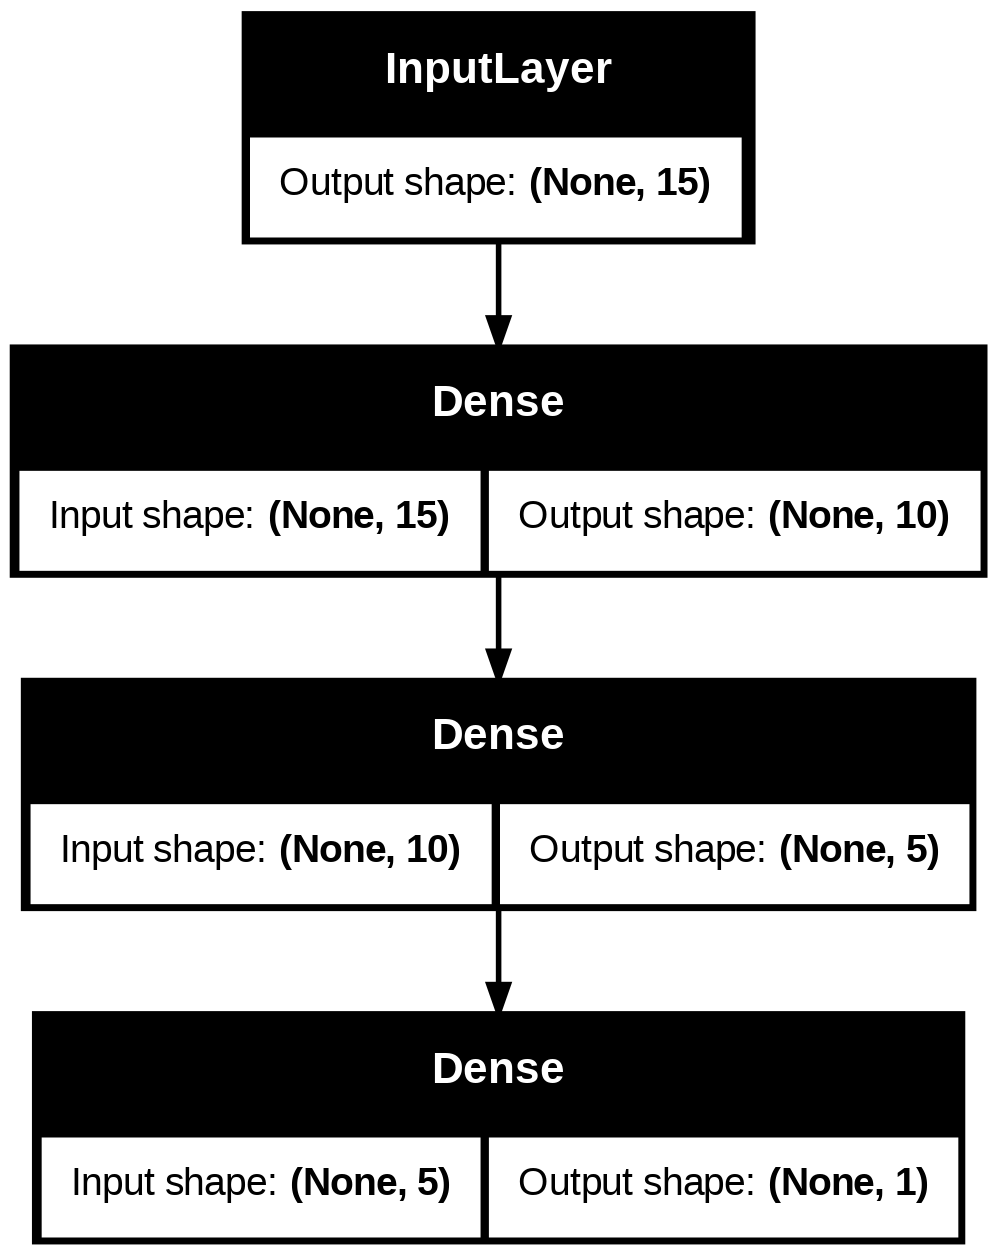

In [31]:
model = model_creator()
plot_model(model, show_shapes = True)

In [32]:
class SaveBestModel(tf.keras.callbacks.Callback):
    def __init__(self, save_best_metric='val_loss', this_max=False):
        self.save_best_metric = save_best_metric
        self.max = this_max
        if this_max:
            self.best = float('-inf')
        else:
            self.best = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        metric_value = logs[self.save_best_metric]
        if self.max:
            if metric_value > self.best:
                self.best = metric_value
                self.best_weights = self.model.get_weights()

        else:
            if metric_value < self.best:
                self.best = metric_value
                self.best_weights= self.model.get_weights()

In [40]:
best_model_saver = SaveBestModel('val_loss')

model = model_creator()

lr = 0.0001
ep = 100
opt = optimizers.Adam(learning_rate=lr, decay=lr / ep)

model.compile(loss = 'binary_crossentropy', optimizer=opt)

history  = model.fit(x = x_train_added_scaled, y = y_train_encoded,
                     validation_split = 0.25, epochs = ep, callbacks=[best_model_saver], batch_size = 256)

model.set_weights(best_model_saver.best_weights)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5080 - val_loss: 0.4760
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4542 - val_loss: 0.4255
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4083 - val_loss: 0.3831
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3704 - val_loss: 0.3484
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3398 - val_loss: 0.3208
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3156 - val_loss: 0.2990
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2965 - val_loss: 0.2818
Epoch 8/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2814 - val_loss: 0.2681
Epoch 9/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2693 - val_loss: 0.2569
Epoch 10/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2595 - val_loss: 0.2478
Epoch 11/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2515 - val_loss: 0.2403
Epoch 12/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

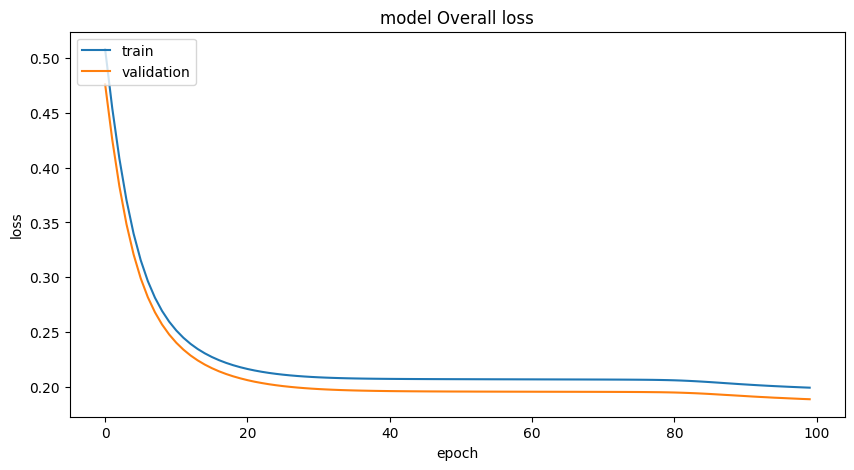

In [41]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model Overall loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# **Model Evaluation**

In [42]:
y_train_pred = model.predict(x_train_added_scaled)
y_test_pred = model.predict(x_test_added_scaled)

1311/1311 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [44]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_encoded, y_test_pred.round()))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     13275
           1       0.00      0.00      0.00       705

    accuracy                           0.95     13980
   macro avg       0.47      0.50      0.49     13980
weighted avg       0.90      0.95      0.93     13980



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
confusion_matrix(y_test_encoded, y_test_pred.round())

array([[13275,     0],
       [  705,     0]])